In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\ADMIN\Desktop\Datasets\TPE-SalesDataset(1).csv")
df.head()

,ID,StaffUtilise,IsSchoolHoliday,IsHoliday,Customers,Sales,SalesAmount
0,1,Low,1,0,11,5,5263
1,2,Low,1,1,13,6,6064
2,3,Medium,1,0,16,8,8314
3,4,Medium,1,0,30,14,13995
4,5,High,?,?,?,?,?


In [3]:
df.describe()

,ID
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               2000 non-null   int64 
 1   StaffUtilise     2000 non-null   object
 2   IsSchoolHoliday  2000 non-null   object
 3   IsHoliday        2000 non-null   object
 4   Customers        2000 non-null   object
 5   Sales            2000 non-null   object
 6   SalesAmount      2000 non-null   object
dtypes: int64(1), object(6)
memory usage: 109.5+ KB


In [5]:
# replace '?' with NaN
df = df.replace('?',np.nan)
#convert columns to numerics
for col in ['Customers','Sales','SalesAmount']:
    df[col] = pd.to_numeric(df[col],errors = 'coerce')
# convert binary columns to numeric
df['IsSchoolHoliday'] = pd.to_numeric(df['IsSchoolHoliday'],errors = 'coerce')
df['IsHoliday'] = pd.to_numeric(df['IsHoliday'],errors = 'coerce')

In [6]:
df.isnull().sum()

ID                 0
StaffUtilise       0
IsSchoolHoliday    1
IsHoliday          1
Customers          7
Sales              7
SalesAmount        8
dtype: int64

In [7]:
# filling in null values
df['IsSchoolHoliday'] = df['IsSchoolHoliday'].fillna(df['IsSchoolHoliday'].mean())
df['IsHoliday'] = df['IsHoliday'].fillna(df['IsHoliday'].median())
df['Customers'] = df['Customers'].fillna(df['Customers'].mean())
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['SalesAmount'] = df['SalesAmount'].fillna(df['SalesAmount'].median())

In [8]:
df.head()

,ID,StaffUtilise,IsSchoolHoliday,IsHoliday,Customers,Sales,SalesAmount
0,1,Low,1.000000,0.0,11.000000,5.000000,5263.0
1,2,Low,1.000000,1.0,13.000000,6.000000,6064.0
2,3,Medium,1.000000,0.0,16.000000,8.000000,8314.0
3,4,Medium,1.000000,0.0,30.000000,14.000000,13995.0
4,5,High,0.837419,0.0,16.543904,8.572002,8100.0


In [9]:
df.isnull().sum()

ID                 0
StaffUtilise       0
IsSchoolHoliday    0
IsHoliday          0
Customers          0
Sales              0
SalesAmount        0
dtype: int64

In [10]:
sns.set(style = 'whitegrid')

C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


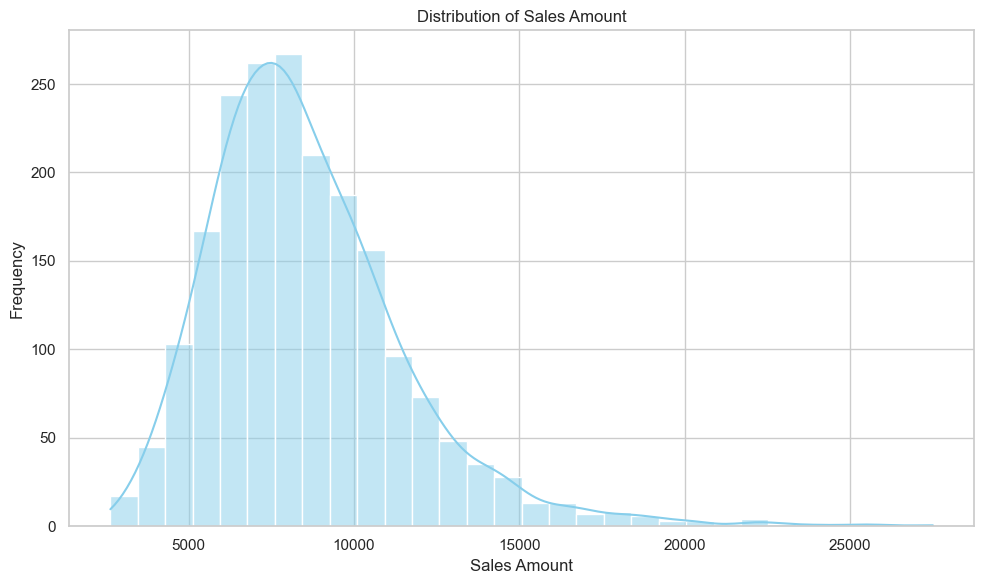

In [11]:
# Distribution of Sales Amount using Histoplot
plt.figure(figsize=(10,6))
sns.histplot(df['SalesAmount'],kde = True,bins = 30,color = 'skyblue')
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

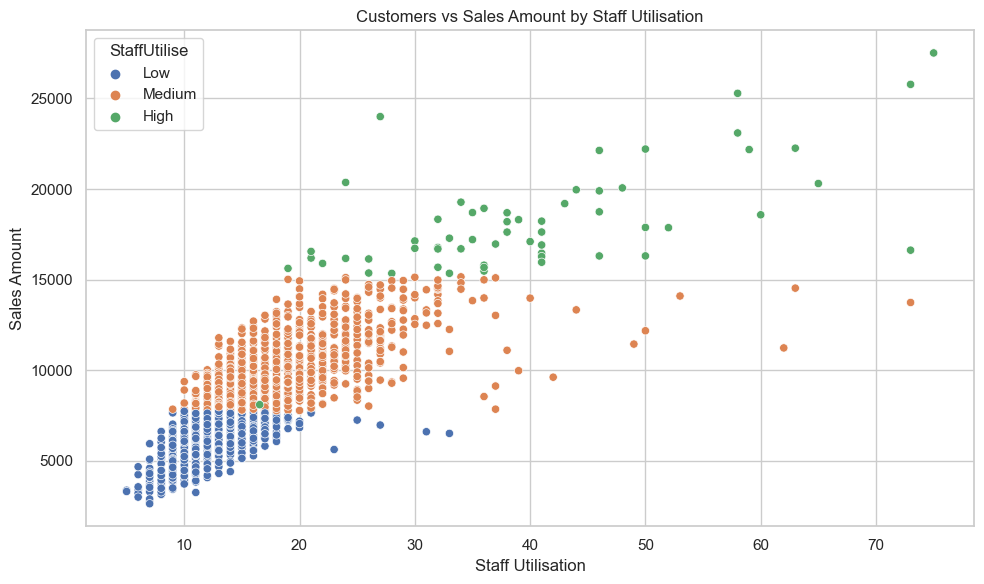

In [12]:
# customers vs Sales Amount based on staff utilization models
plt.figure(figsize =(10,6))
sns.scatterplot(x = 'Customers',y = 'SalesAmount',data = df, hue = 'StaffUtilise') 
plt.title('Customers vs Sales Amount by Staff Utilisation')
plt.xlabel('Staff Utilisation')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

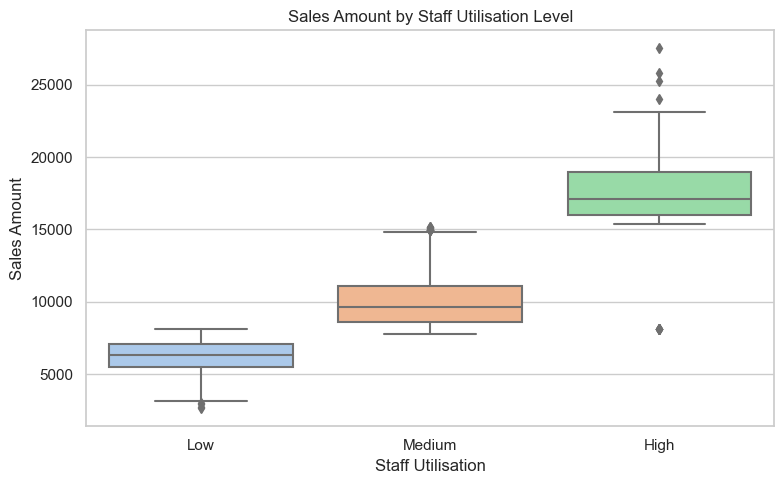

In [13]:
# Sales Amount by Staff Utilisation
plt.figure(figsize =(8,5))
sns.boxplot(x = 'StaffUtilise',y = 'SalesAmount', data = df,palette = 'pastel')
plt.title('Sales Amount by Staff Utilisation Level')
plt.xlabel('Staff Utilisation')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

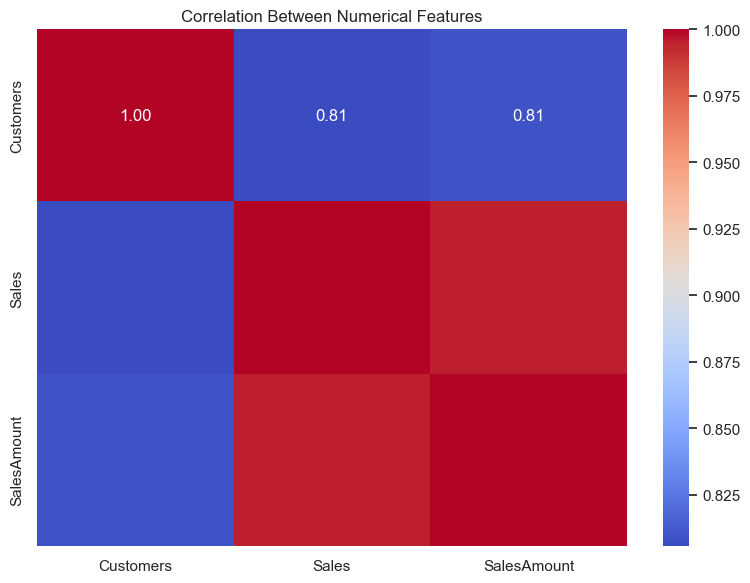

In [14]:
# Correlation heatmap
plt.figure(figsize =(8,6))
corr = df[['Customers','Sales','SalesAmount']].corr()
sns.heatmap(corr, annot = True,cmap = 'coolwarm',fmt = ".2f")
plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

In [15]:
# saving the cleaned dataframe to my desktop as csv file
file_path = r"C:\Users\ADMIN\Desktop\Datasets\TPE_Sales_Final2.csv"

df.to_csv(file_path, index = False)

In [16]:
# convert string values to numerical 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['StaffUtilise'] = le.fit_transform(df['StaffUtilise'])
df.head()

,ID,StaffUtilise,IsSchoolHoliday,IsHoliday,Customers,Sales,SalesAmount
0,1,1,1.000000,0.0,11.000000,5.000000,5263.0
1,2,1,1.000000,1.0,13.000000,6.000000,6064.0
2,3,2,1.000000,0.0,16.000000,8.000000,8314.0
3,4,2,1.000000,0.0,30.000000,14.000000,13995.0
4,5,0,0.837419,0.0,16.543904,8.572002,8100.0


In [17]:
# define features and target y
X = df.drop(columns = ['ID','SalesAmount'],axis = 1)
y = df['SalesAmount']

In [18]:
# model training
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [19]:
# train and test using Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

# predict
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

# print out the results
print(f"Mean Squared Error : {mse:.4f}")
print(f"R-squared : {r2:.4f}")

Mean Squared Error : 4326342.9800
R-squared : 0.5936


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Using random Forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train,y_train)

# testing
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

# print out the results
print(f"Mean Squared Error : {mse:.4f}")
print(f"R-squared : {r2:.4f}")

Mean Squared Error : 192083.5680
R-squared : 0.9820


In [21]:
# Using XGBoost
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)

# testing
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

# print out the results
print(f"Mean Squared Error : {mse:.4f}")
print(f"R-squared : {r2:.4f}")

Mean Squared Error : 88416.2276
R-squared : 0.9917
